In [27]:
import pandas as pd
from pathlib import Path
import numpy as np

In [50]:
import os
full_numerics_dir = '/Users/riccardoconci/Local_documents/Counterfactual_ICU/data/mimic_3_data/processed_data/full_trajectories'

numerics_files = os.listdir(full_numerics_dir)
len(numerics_files)

8172

In [51]:
import pandas as pd

records = pd.read_csv(
    "/Users/riccardoconci/Local_documents/Counterfactual_ICU/data/mimic_3_data/processed_data/useful_csv/RECORDS-numerics.txt",
    sep="\t", header=None
)

# Split the path into columns
split_cols = records[0].str.split("/", expand=True)
split_cols.columns = ["dir1", "dir2", "filename"]

# Clean dir2: strip leading "p", then cast to int to drop leading zeros
split_cols["dir2_clean"] = split_cols["dir2"].str.lstrip("p").astype(int)

print(split_cols.head())

  dir1     dir2                   filename  dir2_clean
0  p00  p000020  p000020-2183-04-28-17-47n          20
1  p00  p000030  p000030-2172-10-16-12-22n          30
2  p00  p000033  p000033-2116-12-24-12-35n          33
3  p00  p000033  p000033-2116-12-25-13-11n          33
4  p00  p000052  p000052-2191-01-10-02-21n          52


In [52]:
split_cols

,dir1,dir2,filename,dir2_clean
0,p00,p000020,p000020-2183-04-28-17-47n,20
1,p00,p000030,p000030-2172-10-16-12-22n,30
2,p00,p000033,p000033-2116-12-24-12-35n,33
3,p00,p000033,p000033-2116-12-25-13-11n,33
4,p00,p000052,p000052-2191-01-10-02-21n,52
...,...,...,...,...
22242,p09,p099982,p099982-2157-01-06-16-31n,99982
22243,p09,p099982,p099982-2157-02-16-17-37n,99982
22244,p09,p099983,p099983-2193-04-26-12-01n,99983
22245,p09,p099992,p099992-2144-07-25-20-39n,99992


In [53]:
icu_stays = pd.read_csv('/Users/riccardoconci/Local_documents/Counterfactual_ICU/data/mimic_3_data/input_data/ICUSTAYS.csv')

In [54]:
icu_stays['HADM_ID'].nunique()

57786

In [55]:
subject_ids_with_waveforms = set(icu_stays['SUBJECT_ID'].unique()) & set(split_cols['dir2_clean'])

In [56]:
len(subject_ids_with_waveforms)

10260

In [57]:
icu_stays_w_waveforms = icu_stays[icu_stays['SUBJECT_ID'].isin(subject_ids_with_waveforms)]

In [58]:
icu_stays_w_waveforms['HADM_ID'].nunique()

15822

In [19]:
icu_stays_w_waveforms['HADM_ID'].nunique() / icu_stays['HADM_ID'].nunique() *100

27.380334337036654

In [20]:
icu_stays_w_waveforms['SUBJECT_ID'].nunique()

10260

In [59]:
items_df = pd.read_csv('/Users/riccardoconci/Local_documents/Counterfactual_ICU/data/mimic_3_data/input_data/D_ITEMS.csv')

items_df.head()

,ROW_ID,ITEMID,LABEL,ABBREVIATION,DBSOURCE,LINKSTO,CATEGORY,UNITNAME,PARAM_TYPE,CONCEPTID
0,457,497,Patient controlled analgesia (PCA) [Inject],NaN,carevue,chartevents,NaN,NaN,NaN,NaN
1,458,498,PCA Lockout (Min),NaN,carevue,chartevents,NaN,NaN,NaN,NaN
2,459,499,PCA Medication,NaN,carevue,chartevents,NaN,NaN,NaN,NaN
3,460,500,PCA Total Dose,NaN,carevue,chartevents,NaN,NaN,NaN,NaN
4,461,501,PCV Exh Vt (Obser),NaN,carevue,chartevents,NaN,NaN,NaN,NaN


In [60]:
INPUT_DATA_DIR = Path('/Users/riccardoconci/Local_documents/Counterfactual_ICU/data/mimic_3_data/input_data')

hadm_ids = icu_stays_w_waveforms['HADM_ID'].unique()


In [61]:
def attach_item_labels(inputs_df: pd.DataFrame, items_df: pd.DataFrame) -> pd.DataFrame:
    """
    Adds a string label for each item_id using D_ITEMS.
    Creates a new column 'item_label'. If no match, falls back to str(item_id).
    """
    # tolerate case differences (MIMIC-III/IV)
    items = items_df.rename(columns=str.lower)
    if not {"itemid", "label"}.issubset(items.columns):
        raise ValueError("items_df must have columns ITEMID and LABEL (any case).")

    items_slim = items[["itemid", "label"]].drop_duplicates()

    df = inputs_df.merge(items_slim, left_on="item_id", right_on="itemid", how="left")
    df = df.drop(columns=["itemid"])
    df["item_label"] = df["label"].fillna(df["item_id"].astype(str))
    df = df.drop(columns=["label"])  # keep things tidy (label now lives in item_label)
    return df

In [181]:
import pandas as pd
import numpy as np
from typing import Optional


def build_inputs_df(df: pd.DataFrame) -> pd.DataFrame:
    """
    Clean IV/medication input events and return a tidy dataframe with:
       subject_id, hadm_id, item_id, input_name, input_class,
       start_time, end_time, rate, rate_uom,
       patientweight,
       rate/weight,           # weight-normalized rate
       rate/weight_capped,    # per-item_id cap at 95th percentile
       rate/weight_norm       # per-item_id 0–1 normalization (divide by 95th pct)

    Rules:
    - Remove cancelled/rejected rows.
    - If rate_uom already encodes per-kg (e.g., 'mcg/kg/min', 'per kg'), then 'rate/weight' == 'rate'.
    - Otherwise, 'rate/weight' = rate / patientweight.
    - patientweight values of 1 or NaN are replaced with the cohort mean of valid weights.
    - For each item_id, cap 'rate/weight' at the 95th percentile.
    - Normalize per item_id by dividing by the 95th percentile.
    - Sorted by hadm_id, item_id, start_time.
    """
    if df.empty:
        return pd.DataFrame()

    # ---- Column resolver
    lower = {c.lower(): c for c in df.columns}

    def pick(*cands: str) -> Optional[str]:
        for c in cands:
            if c.lower() in lower:
                return lower[c.lower()]
        return None

    col_subject = pick("subject_id", "subjectid")
    col_hadm = pick("hadm_id", "hadmid")
    col_item = pick("item_id", "itemid")
    col_name = pick("ordercategoryname")
    col_class = pick("ordercategorydescription")
    col_start = pick("start_time", "starttime", "startdate", "charttime")
    col_end = pick("end_time", "endtime", "enddate", "stoptime")
    col_rate = pick("rate")
    col_rate_u = pick("rate_uom", "rateuom")
    col_weight = pick("patientweight", "weight", "actualbedweight")

    needed = [col_subject, col_hadm, col_item, col_start, col_end, col_rate]
    if any(c is None for c in needed):
        raise ValueError(f"Missing required columns; found: {needed}")

    # ---- Remove cancelled/rejected
    cancel_cols = [
        c
        for c in [
            pick("cancelreason"),
            pick("iscanceled"),
            pick("is_canceled"),
            pick("iscancelled"),
            pick("is_cancelled"),
            pick("canceled"),
            pick("cancelled"),
        ]
        if c is not None
    ]
    status_col = pick("statusdescription", "status", "orderstatus")
    comments_cancel_col = pick("comments_cancelledby", "comments_canceledby")

    keep = pd.Series(True, index=df.index)
    for c in cancel_cols:
        s = df[c]
        keep &= (
            s.isna()
            | (s == 0)
            | (s is False)
            | (s.astype(str).str.strip().isin(["0", "False", "false"]))
        )
    if status_col is not None:
        keep &= ~df[status_col].astype(str).str.contains(
            r"cancel|reject|discontinu", case=False, na=False
        )
    if comments_cancel_col is not None:
        keep &= df[comments_cancel_col].isna()

    dfc = df.loc[keep].copy()

    # ---- Select & normalize
    out_cols = [
        col_subject,
        col_hadm,
        col_item,
        col_name,
        col_class,
        col_start,
        col_end,
        col_rate,
    ]
    if col_rate_u is not None:
        out_cols.append(col_rate_u)
    if col_weight is not None:
        out_cols.append(col_weight)

    out = dfc[out_cols].copy()

    # Convert datetimes
    out[col_start] = pd.to_datetime(out[col_start], errors="coerce", utc=True)
    out[col_end] = pd.to_datetime(out[col_end], errors="coerce", utc=True)

    # Numeric conversions
    out[col_rate] = pd.to_numeric(out[col_rate], errors="coerce")
    if col_weight is not None:
        out[col_weight] = pd.to_numeric(out[col_weight], errors="coerce")

    # ---- Rename to desired schema (normalize names)
    rename_map = {
        col_subject: "subject_id",
        col_hadm: "hadm_id",
        col_item: "item_id",
        col_name: "input_name",
        col_class: "input_class",
        col_start: "start_time",
        col_end: "end_time",
        col_rate: "rate",
    }
    if col_rate_u is not None:
        rename_map[col_rate_u] = "rate_uom"
    if col_weight is not None:
        rename_map[col_weight] = "patientweight"

    out = out.rename(columns=rename_map)

    # Ensure expected columns exist
    for must_col in ["input_name", "input_class", "rate_uom", "patientweight"]:
        if must_col not in out.columns:
            out[must_col] = pd.NA

    # ---- Clean patientweight: replace 1 or NaN with mean of valid weights
    pw = pd.to_numeric(out["patientweight"], errors="coerce")
    valid = pw[(~pw.isna()) & (pw != 1)]
    if not valid.empty:
        mean_wt = valid.mean()
        pw = pw.mask((pw.isna()) | (pw == 1), mean_wt)
    out["patientweight"] = pw

    # ---- Compute rate/weight with per-kg guard
    ru = out["rate_uom"].astype(str)
    is_perkg = ru.str.contains(r"/\s*kg\b", case=False, na=False) | ru.str.contains(
        r"\bper\s*kg\b", case=False, na=False
    )

    rw = pd.Series(np.nan, index=out.index, dtype="float64")
    rw.loc[is_perkg] = out.loc[is_perkg, "rate"]
    denom = out["patientweight"].replace({0: np.nan})
    rw.loc[~is_perkg] = out.loc[~is_perkg, "rate"] / denom.loc[~is_perkg]
    out["rate/weight"] = rw

    # ---- Per-item_id capping at 95th percentile
    p95 = out.groupby("item_id")["rate/weight"].transform(
        lambda x: x.quantile(0.95)
    )
    out["rate/weight_capped"] = out["rate/weight"].clip(upper=p95)

    # ---- Per-item_id normalization by 95th percentile
    safe_p95 = p95.where((p95 > 0) & (~p95.isna()))
    norm = out["rate/weight_capped"] / safe_p95
    out["rate/weight_norm"] = norm.clip(lower=0, upper=1)

    # ---- Sort
    out = out.sort_values(
        ["hadm_id", "item_id", "start_time"], kind="mergesort", na_position="last"
    )

    return out[
        [
            "subject_id",
            "hadm_id",
            "item_id",
            "input_name",
            "input_class",
            "start_time",
            "end_time",
            "rate",
            "rate_uom",
            "patientweight",
            "rate/weight",
            "rate/weight_capped",
            "rate/weight_norm",
        ]
    ].reset_index(drop=True)

In [182]:



inputevents_mv_df = pd.read_csv(INPUT_DATA_DIR / "INPUTEVENTS_MV.csv")
inputevents_mv_df = build_inputs_df(inputevents_mv_df)
inputevents_mv_df = attach_item_labels(inputevents_mv_df, items_df)
inputevents_mv_df = inputevents_mv_df[inputevents_mv_df["hadm_id"].isin(hadm_ids)]
inputevents_mv_df = inputevents_mv_df.sort_values(
    ["hadm_id", "start_time"], ascending=[True, True]
).set_index("hadm_id", drop=False)
inputevents_mv_df.head()

,subject_id,hadm_id,item_id,input_name,input_class,start_time,end_time,rate,rate_uom,patientweight,rate/weight,rate/weight_capped,rate/weight_norm,item_label
hadm_id,,,,,,,,,,,,,,
100001,58526,100001,223258,01-Drips,Continuous Med,2117-09-11 12:50:00+00:00,2117-09-11 12:55:00+00:00,5.000000,units/hour,99.0,0.050505,0.050505,0.265860,Insulin - Regular
100001,58526,100001,225158,01-Drips,Continuous Med,2117-09-11 12:50:00+00:00,2117-09-11 12:55:00+00:00,5.000000,mL/hour,99.0,0.050505,0.050505,0.027003,NaCl 0.9%
100001,58526,100001,223258,01-Drips,Continuous Med,2117-09-11 12:55:00+00:00,2117-09-11 14:00:00+00:00,6.996487,units/hour,99.0,0.070672,0.070672,0.372017,Insulin - Regular
100001,58526,100001,225158,01-Drips,Continuous Med,2117-09-11 12:55:00+00:00,2117-09-11 14:00:00+00:00,6.996487,mL/hour,99.0,0.070672,0.070672,0.037786,NaCl 0.9%
100001,58526,100001,225159,02-Fluids (Crystalloids),Continuous IV,2117-09-11 13:00:00+00:00,2117-09-11 13:47:00+00:00,75.000000,mL/hour,99.0,0.757576,0.757576,0.169912,NaCl 0.45%


In [183]:
all_trigger_meds = pd.read_csv('/Users/riccardoconci/Local_documents/Counterfactual_ICU/data/mimic_3_data/processed_data/useful_csv/all_trigger_meds.csv')


In [184]:
all_trigger_meds

,moa,general_name,item_ids
0,Increase Intravascular Volume (Preload),NaCl 0.9% (Normal Saline),"225158,30018,40850,40865,41490,508822"
1,Increase Intravascular Volume (Preload),Lactated Ringers (LR),"225828,30021,27193"
2,Increase Intravascular Volume (Preload),Albumin 5%,"220864,30008,615"
3,Increase Intravascular Volume (Preload),Albumin 25%,"220862,30009,1278"
4,Increase Intravascular Volume (Preload),Hetastarch (Hespan),"225174,30012"
5,Increase Intravascular Volume (Preload),Dextran 40,"225795,30011"
6,Increase Intravascular Volume (Preload),Packed Red Blood Cells (PRBCs),"225168,30001,30179,30004,30104"
7,Increase Total Peripheral Resistance (Afterload),Phenylephrine (Neosynephrine),"221749,30127,30128,4679,122737"
8,Increase Total Peripheral Resistance (Afterload),Norepinephrine (Levophed),"221906,30047,30120,9413,100132"
9,Increase Total Peripheral Resistance (Afterload),Vasopressin,"222315,30051,39670"


In [185]:
trigger_itemids = (
    all_trigger_meds["item_ids"]
    .str.split(",")                 # split into lists of strings
    .explode()                      # flatten into one long Series
    .str.strip()                    # remove spaces
    .astype(int)                    # convert to ints
    .tolist()                       # back to Python list
)

In [186]:
inputevents_mv_df['item_id'] = inputevents_mv_df['item_id'].astype(int)

In [187]:
inputevents_mv_df_trigger_filtered = inputevents_mv_df[inputevents_mv_df["item_id"].isin(trigger_itemids)]
inputevents_mv_df_trigger_filtered = inputevents_mv_df_trigger_filtered[~inputevents_mv_df_trigger_filtered['input_name'].isin(['08-Antibiotics (IV)', '10-Prophylaxis (IV)'])]


In [188]:
per_item_summary = (
    inputevents_mv_df_trigger_filtered.groupby("item_label")["rate/weight_norm"]
    .describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99])
)
per_item_summary

,count,mean,std,min,25%,50%,75%,95%,99%,max
item_label,,,,,,,,,,
Albumin 25%,4504.0,0.438056,0.218645,0.026662,0.280011,0.365278,0.510680,1.000000,1.000000,1.000000
Albumin 5%,4220.0,0.456963,0.238892,0.026688,0.261205,0.409222,0.584602,1.000000,1.000000,1.000000
Dextran 40,2.0,0.147839,0.000000,0.147839,0.147839,0.147839,0.147839,0.147839,0.147839,0.147839
Dopamine,5163.0,0.366715,0.241711,0.025006,0.200129,0.298089,0.501102,0.998510,1.000000,1.000000
Epinephrine,3160.0,0.274453,0.241401,0.018217,0.104146,0.196947,0.364730,0.837367,1.000000,1.000000
Hetastarch (Hespan) 6%,29.0,0.607410,0.454703,0.028641,0.042909,0.967874,0.983333,1.000000,1.000000,1.000000
Isuprel,17.0,0.459117,0.232918,0.045170,0.406532,0.407775,0.504092,0.903746,0.980749,1.000000
LR,12743.0,0.171066,0.229810,0.000037,0.066492,0.098415,0.145923,0.864600,1.000000,1.000000
Milrinone,2820.0,0.524789,0.221995,0.017673,0.353118,0.529802,0.706431,1.000000,1.000000,1.000000


array([[<Axes: title={'center': 'Albumin 25%'}>,
        <Axes: title={'center': 'Albumin 5%'}>,
        <Axes: title={'center': 'Dextran 40'}>,
        <Axes: title={'center': 'Dopamine'}>],
       [<Axes: title={'center': 'Epinephrine'}>,
        <Axes: title={'center': 'Hetastarch (Hespan) 6%'}>,
        <Axes: title={'center': 'Isuprel'}>,
        <Axes: title={'center': 'LR'}>],
       [<Axes: title={'center': 'Milrinone'}>,
        <Axes: title={'center': 'NaCl 0.9%'}>,
        <Axes: title={'center': 'Norepinephrine'}>,
        <Axes: title={'center': 'Packed Red Blood Cells'}>],
       [<Axes: title={'center': 'Phenylephrine'}>,
        <Axes: title={'center': 'Vasopressin'}>, <Axes: >, <Axes: >]],
      dtype=object)

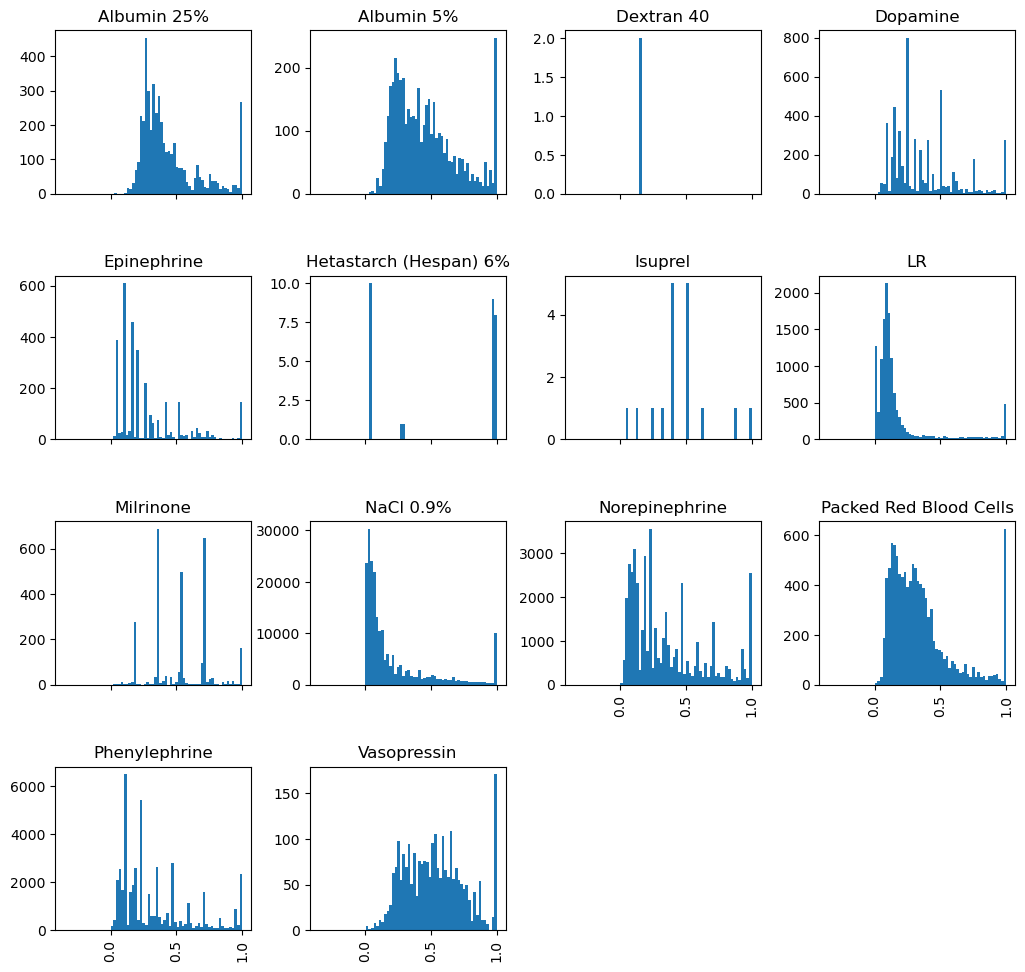

In [190]:
inputevents_mv_df_trigger_filtered.hist(column="rate/weight_norm", by="item_label", bins=50, figsize=(12,12), sharex=True)

In [191]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_rate_distributions(df, items=None, bins=50, max_cols=3):
    """
    Plot normalized rate/weight distributions for selected items.
    If items is None, plot for all unique item_labels in the dataframe.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing 'item_label' and 'rate/weight_norm'
    items : list or None
        List of item_labels to plot. If None, all unique item_labels are used.
    bins : int
        Number of histogram bins.
    max_cols : int
        Max number of subplot columns in grid layout.
    """
    sns.set_style("whitegrid")
    
    # Decide which items to plot
    if items is None:
        items = sorted(df["item_label"].dropna().unique())
    
    n_items = len(items)
    n_cols = min(max_cols, n_items)
    n_rows = (n_items + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 3*n_rows), sharex=True)
    axes = axes.flatten() if n_items > 1 else [axes]

    for ax, item in zip(axes, items):
        data = df.loc[df["item_label"] == item, "rate/weight_norm"].dropna()
        sns.histplot(data, bins=bins, kde=False, ax=ax,
                     color="steelblue", edgecolor="white")
        ax.set_title(f"{item}", fontsize=12, weight="bold")
        ax.set_ylabel("Count")
        ax.set_xlim(0, 1)

    # Remove unused subplots if items don't fill the grid
    for ax in axes[n_items:]:
        ax.remove()

    axes[min(n_items, len(axes)) - 1].set_xlabel("Normalized Rate/Weight")
    plt.tight_layout()
    plt.show()

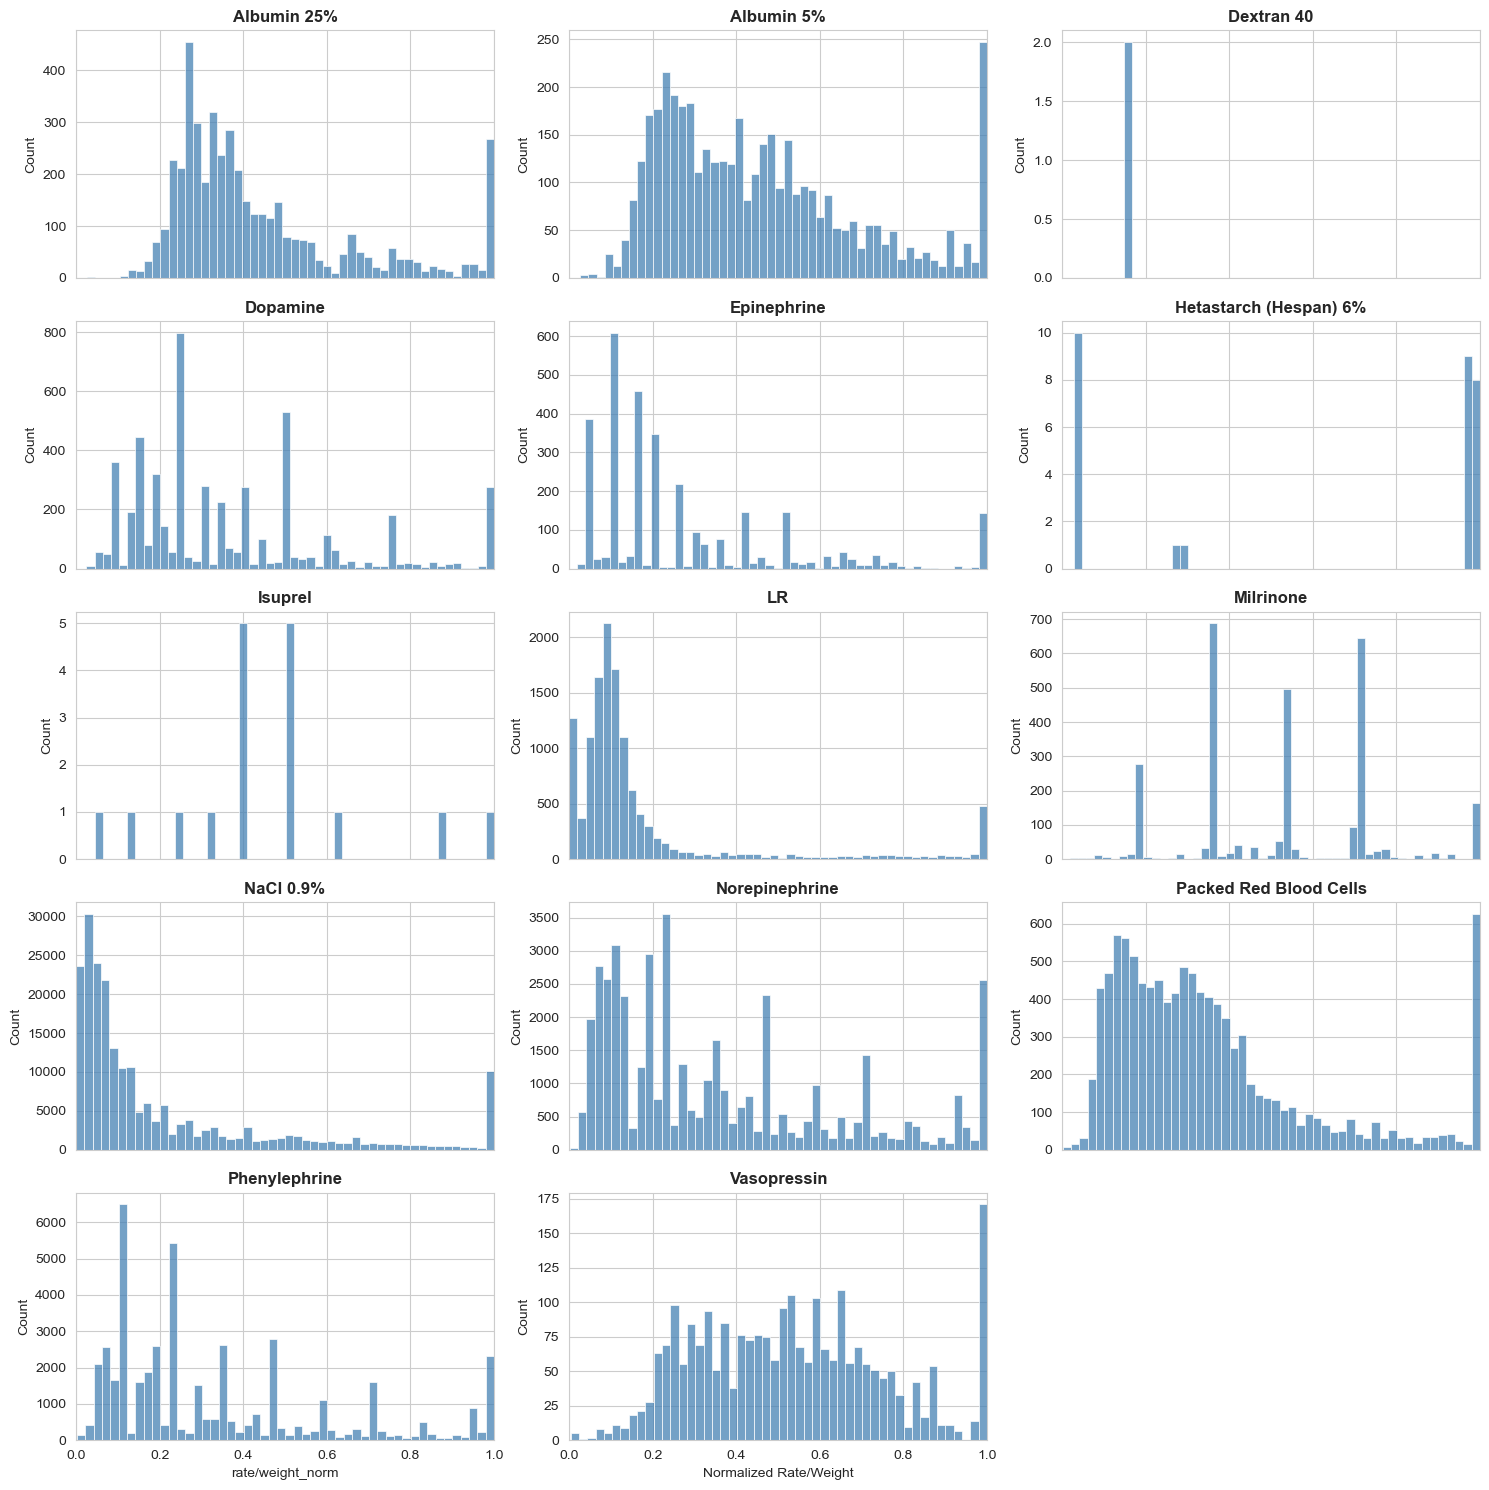

In [192]:
plot_rate_distributions(inputevents_mv_df_trigger_filtered)

In [159]:
original_total_hadm_ids = 57786
inputevents_mv_df_trigger_filtered['hadm_id'].nunique() / original_total_hadm_ids *100

15.80313570761084

In [194]:
inputevents_mv_df_trigger_filtered['input_name'].value_counts()

input_name
01-Drips                    262193
02-Fluids (Crystalloids)     68763
03-IV Fluid Bolus            25410
07-Blood Products            10424
04-Fluids (Colloids)          8755
Name: count, dtype: int64

In [195]:
inputevents_mv_df_trigger_filtered['item_label'].value_counts()

item_label
NaCl 0.9%                 232209
Phenylephrine              46464
Norepinephrine             44611
LR                         19393
Packed Red Blood Cells     10424
Dopamine                    5163
Albumin 25%                 4504
Albumin 5%                  4220
Epinephrine                 3160
Milrinone                   2820
Vasopressin                 2529
Hetastarch (Hespan) 6%        29
Isuprel                       17
Dextran 40                     2
Name: count, dtype: int64

In [162]:
#for i in list(inputevents_mv_df_trigger_filtered['input_name'].unique()):
#    print(i)
#    print(inputevents_mv_df_trigger_filtered[inputevents_mv_df_trigger_filtered['input_name'] == i]['item_label'].value_counts())

In [196]:
nan_by_input = (
    inputevents_mv_df_trigger_filtered
    .groupby("input_name")["rate/weight"]
    .apply(lambda s: s.isna().sum())
)

totals_by_input = inputevents_mv_df_trigger_filtered["input_name"].value_counts()

nan_summary = pd.DataFrame({
    "total": totals_by_input,
    "n_missing": nan_by_input,
})
nan_summary["percent_missing"] = 100 * nan_summary["n_missing"] / nan_summary["total"]
print(nan_summary)

                           total  n_missing  percent_missing
input_name                                                  
01-Drips                  262193          0              0.0
02-Fluids (Crystalloids)   68763          0              0.0
03-IV Fluid Bolus          25410      25410            100.0
04-Fluids (Colloids)        8755          0              0.0
07-Blood Products          10424          0              0.0


In [197]:
nan_by_label = (
    inputevents_mv_df_trigger_filtered
    .groupby("item_label")["rate/weight"]
    .apply(lambda s: s.isna().sum())
    .sort_values(ascending=False)
)

print(nan_by_label.head(20))  # top 20 labels with most missing

item_label
NaCl 0.9%                 18760
LR                         6650
Albumin 25%                   0
Albumin 5%                    0
Dextran 40                    0
Dopamine                      0
Epinephrine                   0
Hetastarch (Hespan) 6%        0
Isuprel                       0
Milrinone                     0
Norepinephrine                0
Packed Red Blood Cells        0
Phenylephrine                 0
Vasopressin                   0
Name: rate/weight, dtype: int64


In [198]:
nan_by_item_id = (
    inputevents_mv_df_trigger_filtered
    .groupby("item_id")["rate/weight"]
    .apply(lambda s: s.isna().sum())
    .sort_values(ascending=False)
)

print(nan_by_item_id)  # top 20 labels with most missing

item_id
225158    18760
225828     6650
220862        0
220864        0
221289        0
221662        0
221749        0
221906        0
221986        0
222315        0
225168        0
225174        0
225795        0
227692        0
Name: rate/weight, dtype: int64


In [199]:
inputevents_mv_df_trigger_filtered.head()

,subject_id,hadm_id,item_id,input_name,input_class,start_time,end_time,rate,rate_uom,patientweight,rate/weight,rate/weight_capped,rate/weight_norm,item_label
hadm_id,,,,,,,,,,,,,,
100001,58526,100001,225158,01-Drips,Continuous Med,2117-09-11 12:50:00+00:00,2117-09-11 12:55:00+00:00,5.000000,mL/hour,99.0,0.050505,0.050505,0.027003,NaCl 0.9%
100001,58526,100001,225158,01-Drips,Continuous Med,2117-09-11 12:55:00+00:00,2117-09-11 14:00:00+00:00,6.996487,mL/hour,99.0,0.070672,0.070672,0.037786,NaCl 0.9%
100001,58526,100001,225158,02-Fluids (Crystalloids),Continuous IV,2117-09-11 13:48:00+00:00,2117-09-11 15:48:00+00:00,499.999980,mL/hour,99.0,5.050505,1.870324,1.000000,NaCl 0.9%
100001,58526,100001,225158,01-Drips,Continuous Med,2117-09-11 14:00:00+00:00,2117-09-11 16:12:00+00:00,8.990600,mL/hour,99.0,0.090814,0.090814,0.048555,NaCl 0.9%
100001,58526,100001,225158,02-Fluids (Crystalloids),Continuous IV,2117-09-11 15:59:00+00:00,2117-09-11 16:11:00+00:00,199.999998,mL/hour,99.0,2.020202,1.870324,1.000000,NaCl 0.9%


let's define the following triggers + action clusters:


1) any bolus is a trigger 

2) any uptitration of a medication is a trigger (as long as > of 10% of the previous rate/weight)

3) any new medication 

if we have multiple triggers within 20 mins of the first one, they are clustered in an action cluster as we previously said. 



In [211]:
import pandas as pd
import numpy as np

def compute_triggers_simple(
    df: pd.DataFrame,
    uptitration_rel_threshold: float = 0.25,  # >10% relative increase
    min_abs_change: float = 0.02,             # ignore micro-jitters smaller than this
) -> pd.DataFrame:
    """
    Triggers (evaluated on a normalized rate basis):
      1) Any bolus (input_name contains 'bolus')
      2) Uptitration: (curr - prev) > 0, (curr - prev)/prev > rel_threshold, and abs(curr - prev) >= min_abs_change
      3) New medication: prev == 0 and curr > 0

    Rate basis precedence: rate/weight_norm → rate/weight → rate
    Grouping: subject_id, hadm_id, and item_label (fallback to item_id if needed)
    """
    # --- make a working copy and normalize index without duplicating columns
    df = df.copy()
    if isinstance(df.index, pd.MultiIndex):
        # If any index level name collides with columns, drop it; else keep it
        idx_names = [n for n in df.index.names if n is not None]
        if any(n in df.columns for n in idx_names):
            df = df.reset_index(drop=True)
        else:
            df = df.reset_index()
    else:
        idx_name = df.index.name
        if idx_name is not None and idx_name in df.columns:
            df = df.reset_index(drop=True)
        else:
            df = df.reset_index()

    # --- coerce times
    for c in ("start_time", "end_time"):
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors="coerce")

    # --- unified rate (prefer normalized)
    df["rate_norm"] = (
        pd.to_numeric(df.get("rate/weight_norm"), errors="coerce")
        .fillna(pd.to_numeric(df.get("rate/weight"), errors="coerce"))
        .fillna(pd.to_numeric(df.get("rate"), errors="coerce"))
        .fillna(0.0)
    )

    # --- grouping keys: prefer item_label, else item_id
    item_key = "item_label" if "item_label" in df.columns else ("item_id" if "item_id" in df.columns else None)
    group_keys = [k for k in ["subject_id", "hadm_id", item_key] if k and k in df.columns]
    if not group_keys or (item_key is None):
        raise KeyError("Need subject_id, hadm_id, and one of ['item_label','item_id'] to group titrations.")

    # --- order and previous rate
    sort_keys = group_keys + (["start_time"] if "start_time" in df.columns else [])
    df = df.sort_values(sort_keys).copy()
    df["prev_rate"] = df.groupby(group_keys)["rate_norm"].shift(1).fillna(0.0)

    # (1) bolus?
    is_bolus = (
        df["input_name"].str.contains("bolus", case=False, na=False)
        if "input_name" in df.columns else pd.Series(False, index=df.index)
    )

    # (2) uptitration
    prev = df["prev_rate"]
    curr = df["rate_norm"]
    delta = curr - prev
    with np.errstate(divide="ignore", invalid="ignore"):
        rel_increase = np.where(prev > 0, delta / prev, np.nan)
    uptitrate = (delta > 0) & (np.nan_to_num(rel_increase, nan=0.0) > uptitration_rel_threshold) & (delta >= min_abs_change)

    # (3) new medication start
    first_start = (prev == 0) & (curr > 0)

    # compose trigger + reason
    trigger = is_bolus | uptitrate | first_start
    reason = np.where(
        is_bolus, "bolus",
        np.where(uptitrate, f"uptitrate_gt{int(uptitration_rel_threshold*100)}pct_abs>={min_abs_change}",
                 np.where(first_start, "start_new_med", ""))
    )

    df["trigger"] = trigger
    df["trigger_reason"] = reason
    return df

In [212]:
# ---------- ACTION CLUSTERS (20-min window) ----------

def _encounter_keys(df: pd.DataFrame):
    keys = []
    if "subject_id" in df.columns: keys.append("subject_id")
    if "hadm_id"   in df.columns: keys.append("hadm_id")
    if not keys: raise KeyError("Neither 'subject_id' nor 'hadm_id' found.")
    return keys

def compute_action_clusters(
    df_with_triggers: pd.DataFrame,
    window_minutes: int = 20,        # <- per your spec
    min_events_in_cluster: int = 1,  # set 1 so every trigger gets a cluster if alone
) -> pd.DataFrame:
    """
    Non-overlapping clusters within an encounter:
      start at a trigger t0, include all triggers with start_time <= t0+window,
      then jump to the first trigger strictly after that window.
    """
    df = df_with_triggers.copy()
    for col in ("action_cluster_id","action_cluster_size","action_cluster_rank"):
        if col not in df.columns:
            df[col] = np.nan

    enc_keys = _encounter_keys(df)

    def cluster_one_enc(g):
        g = g.sort_values("start_time").copy()
        trig_idx = g.index[g["trigger"]].tolist()
        if not trig_idx:
            return g

        cluster_id = 0
        i = 0
        while i < len(trig_idx):
            start_idx = trig_idx[i]
            t0 = g.loc[start_idx, "start_time"]
            if pd.isna(t0):
                i += 1
                continue
            window_end = t0 + pd.Timedelta(minutes=window_minutes)

            # collect triggers in [t0, window_end]
            members = [start_idx]
            j = i + 1
            while j < len(trig_idx):
                t_next = g.loc[trig_idx[j], "start_time"]
                if pd.isna(t_next) or t_next > window_end:
                    break
                members.append(trig_idx[j])
                j += 1

            if len(members) >= min_events_in_cluster:
                cluster_id += 1
                size = len(members)
                for rank, idx in enumerate(members, start=1):
                    g.at[idx, "action_cluster_id"] = cluster_id
                    g.at[idx, "action_cluster_size"] = size
                    g.at[idx, "action_cluster_rank"] = rank
                # jump to first trigger AFTER window
                i = j
            else:
                i += 1

        return g

    df = df.groupby(enc_keys, group_keys=False).apply(cluster_one_enc)
    # nice dtypes
    df["action_cluster_id"]   = df["action_cluster_id"].astype("Int64")
    df["action_cluster_size"] = df["action_cluster_size"].astype("Int64")
    df["action_cluster_rank"] = df["action_cluster_rank"].astype("Int64")
    return df

In [214]:
trig = compute_triggers_simple(inputevents_mv_df_trigger_filtered, uptitration_rel_threshold=0.25, min_abs_change=0.02)

# Quick sanity: see reasons
print(trig["trigger_reason"].value_counts())


trigger_reason
                               251465
uptitrate_gt25pct_abs>=0.02     65899
start_new_med                   32771
bolus                           25410
Name: count, dtype: int64


In [215]:
trig_clustered = compute_action_clusters(trig, window_minutes=20, min_events_in_cluster=1)



/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_56056/2119798312.py:67: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(enc_keys, group_keys=False).apply(cluster_one_enc)


In [238]:
trig_clustered[['subject_id', 'hadm_id', 'start_time', 'end_time', 'trigger', 'action_cluster_id', 'action_cluster_size', 'action_cluster_rank']].head(50)


,subject_id,hadm_id,start_time,end_time,trigger,action_cluster_id,action_cluster_size,action_cluster_rank
43987,85,112077,2167-07-26 00:00:00+00:00,2167-07-27 07:00:00+00:00,True,1,1,1
43988,85,112077,2167-07-26 02:30:00+00:00,2167-07-26 02:31:00+00:00,True,2,1,1
43989,85,112077,2167-07-26 03:10:00+00:00,2167-07-26 03:11:00+00:00,True,3,1,1
43990,85,112077,2167-07-26 04:30:00+00:00,2167-07-26 04:31:00+00:00,True,4,1,1
43991,85,112077,2167-07-26 05:00:00+00:00,2167-07-26 05:01:00+00:00,True,5,1,1
43992,85,112077,2167-07-27 10:00:00+00:00,2167-07-27 18:36:00+00:00,True,6,1,1
277168,107,174162,2122-05-14 21:24:00+00:00,2122-05-14 22:59:00+00:00,True,1,1,1
277169,107,174162,2122-05-14 21:57:00+00:00,2122-05-14 22:57:00+00:00,True,2,1,1
277170,107,174162,2122-05-14 22:55:00+00:00,2122-05-14 22:56:00+00:00,True,3,1,1
277171,107,174162,2122-05-14 23:10:00+00:00,2122-05-15 00:10:00+00:00,False,<NA>,<NA>,<NA>


## Align with waveforms

In [ ]:
import os
import pyarrow.parquet as pq
from collections import Counter

full_numerics_dir = "/Users/riccardoconci/Local_documents/Counterfactual_ICU/data/mimic_3_data/processed_data/full_trajectories"

numerics_files = os.listdir(full_numerics_dir)
print(f"Found {len(numerics_files)} files")

col_counter = Counter()

for fname in numerics_files:
    fpath = os.path.join(full_numerics_dir, fname)
    try:
        schema = pq.read_schema(fpath)
        col_counter.update(schema.names)
    except Exception as e:
        print(f"Could not read {fname}: {e}")

# Rank columns by how many files they appear in
sorted_cols = col_counter.most_common()



Found 8172 files

Total unique columns: 204
Top 20 columns by frequency:
time_seconds                   8172 / 8172 files
record_name                    8172 / 8172 files
record_start_time              8172 / 8172 files
record_end_time                8172 / 8172 files
hadm_id                        8172 / 8172 files
t0_timestamps                  8172 / 8172 files
icu_admission_time             8155 / 8172 files
HR                             8110 / 8172 files
RESP                           7885 / 8172 files
PULSE                          7470 / 8172 files
SpO2                           6040 / 8172 files
CVP                            3340 / 8172 files
ABPMean                        2811 / 8172 files
ABPSys                         2789 / 8172 files
ABPDias                        2789 / 8172 files
NBPSys                         2706 / 8172 files
NBPDias                        2706 / 8172 files
NBPMean                        2706 / 8172 files
Rhythm Status                  2685 / 8172 fi

In [229]:
print(f"\nTotal unique columns: {len(sorted_cols)}")
print("Top 20 columns by frequency:")
for col, count in sorted_cols[:50]:
    print(f"{col:30s} {count} / {len(numerics_files)} files")


Total unique columns: 204
Top 20 columns by frequency:
time_seconds                   8172 / 8172 files
record_name                    8172 / 8172 files
record_start_time              8172 / 8172 files
record_end_time                8172 / 8172 files
hadm_id                        8172 / 8172 files
t0_timestamps                  8172 / 8172 files
icu_admission_time             8155 / 8172 files
HR                             8110 / 8172 files
RESP                           7885 / 8172 files
PULSE                          7470 / 8172 files
SpO2                           6040 / 8172 files
CVP                            3340 / 8172 files
ABPMean                        2811 / 8172 files
ABPSys                         2789 / 8172 files
ABPDias                        2789 / 8172 files
NBPSys                         2706 / 8172 files
NBPDias                        2706 / 8172 files
NBPMean                        2706 / 8172 files
Rhythm Status                  2685 / 8172 files
PVC Rate per 

In [ ]:
core_to_keep = ['ABP MEAN', 'ABP Mean','ABPMean', 'ART MEAN', 'ART Mean', 'CVP']
plus_to_keep = ['CO', 'HR', 'PAP Mean', 'SpO2', 'RESP']

In [247]:
import os
import pyarrow.parquet as pq

full_numerics_dir = "/Users/riccardoconci/Local_documents/Counterfactual_ICU/data/mimic_3_data/processed_data/full_trajectories"

core_to_keep = ['ABP MEAN', 'ABP Mean','ABPMean', 'ART MEAN', 'ART Mean', 'CVP']

numerics_files = os.listdir(full_numerics_dir)
print(f"Found {len(numerics_files)} files")

files_with_core = []

for fname in numerics_files:
    fpath = os.path.join(full_numerics_dir, fname)
    try:
        schema = pq.read_schema(fpath)
        cols = set(schema.names)
        if any(core in cols for core in core_to_keep):
            files_with_core.append(fname)
    except Exception as e:
        print(f"Could not read {fname}: {e}")

print(f"\nFiles containing at least one core signal ({len(files_with_core)} / {len(numerics_files)}):")
for f in files_with_core[:20]:  # print only first 20 to keep it short
    print(f)

# If you want the full list for further processing:
files_with_core

Found 8172 files

Files containing at least one core signal (5447 / 8172):
full_waveform_169487_p011342-2181-10-16-08-09n.parquet
full_waveform_141494_p069857-2105-04-07-15-53n.parquet
full_waveform_191065_p025313-2210-10-09-14-52n.parquet
full_waveform_172991_p006555-2106-08-19-14-49n.parquet
full_waveform_146741_p009473-2102-11-25-14-06n.parquet
full_waveform_129259_p026688-2173-12-21-15-21n.parquet
full_waveform_125504_p004852-2156-11-05-13-11n.parquet
full_waveform_104136_p012294-2166-08-01-12-26n.parquet
full_waveform_193150_p031061-2181-04-06-14-54n.parquet
full_waveform_167669_p024626-2158-05-02-19-54n.parquet
full_waveform_140427_p021271-2187-08-08-13-57n.parquet
full_waveform_126423_p018166-2129-05-05-21-06n.parquet
full_waveform_168133_p060518-2110-08-08-12-24n.parquet
full_waveform_172954_p017696-2152-01-10-13-41n.parquet
full_waveform_156639_p004465-2121-06-26-11-56n.parquet
full_waveform_184495_p040897-2132-01-30-12-48n.parquet
full_waveform_174194_p013101-2123-09-27-18-27

['full_waveform_169487_p011342-2181-10-16-08-09n.parquet',
 'full_waveform_141494_p069857-2105-04-07-15-53n.parquet',
 'full_waveform_191065_p025313-2210-10-09-14-52n.parquet',
 'full_waveform_172991_p006555-2106-08-19-14-49n.parquet',
 'full_waveform_146741_p009473-2102-11-25-14-06n.parquet',
 'full_waveform_129259_p026688-2173-12-21-15-21n.parquet',
 'full_waveform_125504_p004852-2156-11-05-13-11n.parquet',
 'full_waveform_104136_p012294-2166-08-01-12-26n.parquet',
 'full_waveform_193150_p031061-2181-04-06-14-54n.parquet',
 'full_waveform_167669_p024626-2158-05-02-19-54n.parquet',
 'full_waveform_140427_p021271-2187-08-08-13-57n.parquet',
 'full_waveform_126423_p018166-2129-05-05-21-06n.parquet',
 'full_waveform_168133_p060518-2110-08-08-12-24n.parquet',
 'full_waveform_172954_p017696-2152-01-10-13-41n.parquet',
 'full_waveform_156639_p004465-2121-06-26-11-56n.parquet',
 'full_waveform_184495_p040897-2132-01-30-12-48n.parquet',
 'full_waveform_174194_p013101-2123-09-27-18-27n.parquet

In [248]:
import os
import numpy as np
import pandas as pd
import pyarrow.parquet as pq

import os
import pandas as pd
import pyarrow.parquet as pq
from typing import List, Dict, Iterable



# 1) Representative action time: FIRST trigger start_time per action_cluster_id
def compute_action_times_first_trigger(trig_clustered: pd.DataFrame) -> pd.DataFrame:
    df = trig_clustered.copy()
    # Keep only rows belonging to a cluster and marked as triggers
    df = df[df["trigger"].fillna(False) & df["action_cluster_id"].notna()].copy()

    # Ensure datetime
    df["start_time"] = pd.to_datetime(df["start_time"], errors="coerce", utc=True)

    # Sort so "first" is truly earliest start_time
    df = df.sort_values(["action_cluster_id", "start_time"])

    # Take the earliest start_time per cluster; carry a few identifiers
    firsts = (
        df.groupby("action_cluster_id", as_index=False)
          .agg({
              "start_time": "first",
              "subject_id": "first",
              "hadm_id": "first",
              "item_label": "first",
              "action_cluster_size": "first",
              "action_cluster_rank": "min",
          })
          .rename(columns={"start_time": "action_time"})
    )
    return firsts



# ---- 1) Find waveform files that contain any of the core signals
def list_files_with_core_signals(
    waveform_dir: str,
    core_to_keep: Iterable[str],
    case_insensitive: bool = True,
    limit_print: int = 20,
) -> List[str]:
    """
    Return file paths of .parquet waveforms that contain at least one of the
    'core_to_keep' column names (numerics).
    """
    core = list(core_to_keep)
    if case_insensitive:
        core_lower = {c.lower() for c in core}

    files = [f for f in os.listdir(waveform_dir) if f.endswith(".parquet")]
    files_with_core: List[str] = []

    print(f"Found {len(files)} parquet files in {waveform_dir}")

    for fname in files:
        fpath = os.path.join(waveform_dir, fname)
        try:
            schema = pq.read_schema(fpath)
            names = schema.names
            if case_insensitive:
                cols = {n.lower() for n in names}
                hit = any(c in cols for c in core_lower)
            else:
                cols = set(names)
                hit = any(c in cols for c in core)
            if hit:
                files_with_core.append(fpath)
        except Exception as e:
            print(f"Could not read {fname}: {e}")

    print(
        f"\nFiles containing at least one core signal "
        f"({len(files_with_core)} / {len(files)}):"
    )
    for f in files_with_core[:limit_print]:
        print(os.path.basename(f))
    if len(files_with_core) > limit_print:
        print("...")

    return files_with_core


# 2) Waveform metadata (read only hadm_id + time bounds per file)
def build_waveform_metadata_from_files(file_paths: List[str]) -> pd.DataFrame:
    """
    Reads *only* the metadata columns from a list of parquet files.
    Returns columns: hadm_id, record_name, record_start_time, record_end_time, file_path
    """
    rows = []
    for fpath in file_paths:
        try:
            table = pq.read_table(
                fpath,
                columns=["hadm_id", "record_name", "record_start_time", "record_end_time"],
            )
            df = table.to_pandas()
            df = df[["hadm_id", "record_name", "record_start_time", "record_end_time"]].drop_duplicates()
            df["file_path"] = fpath
            rows.append(df)
        except Exception as e:
            print(f"Skipping {os.path.basename(fpath)}: {e}")

    if not rows:
        return pd.DataFrame(columns=[
            "hadm_id", "record_name", "record_start_time", "record_end_time", "file_path"
        ])

    meta = pd.concat(rows, ignore_index=True)
    meta["record_start_time"] = pd.to_datetime(meta["record_start_time"], errors="coerce", utc=True)
    meta["record_end_time"]   = pd.to_datetime(meta["record_end_time"],   errors="coerce", utc=True)
    return meta


# 3) Interval-overlap join with ±window_minutes around the first trigger time
def align_actions_to_waveforms_first_trigger(
    trig_clustered: pd.DataFrame,
    waveform_meta: pd.DataFrame,
    window_minutes: int = 10,
) -> pd.DataFrame:
    acts = compute_action_times_first_trigger(trig_clustered).copy()

    # Build time windows
    delta = pd.to_timedelta(window_minutes, unit="m")
    acts["window_start"] = acts["action_time"] - delta
    acts["window_end"]   = acts["action_time"] + delta

    # Join on hadm_id (same admission), then filter by interval overlap
    merged = acts.merge(waveform_meta, on="hadm_id", how="inner", suffixes=("", "_wf"))

    mask = (merged["record_start_time"] <= merged["window_end"]) & \
           (merged["record_end_time"]   >= merged["window_start"])

    hit = merged.loc[mask].copy()
    if hit.empty:
        # Nothing overlapped
        return hit

    # Compute overlap bounds and offsets in seconds relative to the file start
    hit["overlap_start"] = hit[["record_start_time", "window_start"]].max(axis=1)
    hit["overlap_end"]   = hit[["record_end_time",   "window_end"]].min(axis=1)

    # Ensure a positive overlap
    hit = hit.loc[hit["overlap_end"] > hit["overlap_start"]].copy()

    # Compute offsets into the waveform file (seconds since record_start_time)
    file_start = hit["record_start_time"].view("int64") // 10**9
    overlap_start = hit["overlap_start"].view("int64") // 10**9
    overlap_end   = hit["overlap_end"].view("int64") // 10**9

    hit["offset_start_seconds"] = (overlap_start - file_start).clip(lower=0)
    hit["offset_end_seconds"]   = (overlap_end   - file_start).clip(lower=0)
    hit["overlap_seconds"]      = hit["offset_end_seconds"] - hit["offset_start_seconds"]

    # Tidy columns
    cols = [
        "action_cluster_id", "subject_id", "hadm_id", "item_label",
        "action_time", "window_start", "window_end",
        "record_name", "file_path", "record_start_time", "record_end_time",
        "overlap_start", "overlap_end", "offset_start_seconds", "offset_end_seconds",
        "overlap_seconds", "action_cluster_size", "action_cluster_rank",
    ]
    cols = [c for c in cols if c in hit.columns]
    hit = hit[cols].sort_values(["hadm_id", "action_time", "record_start_time"]).reset_index(drop=True)
    return hit


# 4) (Optional) pick one “best” waveform per action (largest overlap)
def pick_best_waveform_per_action(aligned: pd.DataFrame) -> pd.DataFrame:
    if aligned.empty:
        return aligned
    best = (
        aligned.sort_values(["action_cluster_id", "overlap_seconds"], ascending=[True, False])
               .groupby("action_cluster_id", as_index=False)
               .head(1)
               .reset_index(drop=True)
    )
    return best

In [ ]:
trig_clustered['hadm_id']

9132

In [252]:
chart_events_filtered_path = '/Users/riccardoconci/Local_documents/Counterfactual_ICU/data/mimic_3_data/temp_dfs/CHARTEVENTS_chartevents.pkl'
chart_events_filtered = pd.read_pickle(chart_events_filtered_path)
chart_events_filtered = chart_events_filtered[chart_events_filtered['value']>0]
chart_events_filtered.head()

,subject_id,hadm_id,itemid,charttime,value,valueuom
1,124,138376,224690,2166-01-16 12:00:00,23.00,insp/min
2,124,138376,224695,2166-01-16 12:00:00,23.00,cmH2O
3,124,138376,224697,2166-01-16 12:00:00,12.00,cmH2O
4,124,138376,224738,2166-01-16 12:00:00,0.85,sec
5,124,138376,225309,2166-01-16 12:00:00,126.00,mmHg


In [ ]:
compute_action_times_first_trigger()

In [ ]:
full_numerics_dir = "/Users/riccardoconci/Local_documents/Counterfactual_ICU/data/mimic_3_data/processed_data/full_trajectories"

core_to_keep = ['ABP MEAN', 'ABP Mean','ABPMean', 'ART MEAN', 'ART Mean', 'CVP']

# 1) Get only files that have at least one core signal
files_with_core = list_files_with_core_signals(
    waveform_dir=full_numerics_dir,
    core_to_keep=core_to_keep,
    case_insensitive=True,  # robust to naming case
)

# 2) Build metadata from just those files
waveform_meta_core = build_waveform_metadata_from_files(files_with_core)

aligned = align_actions_to_waveforms_first_trigger(
    trig_clustered=trig_clustered,
    waveform_meta=waveform_meta_core,
    window_minutes=10,
)

# One “best” file per action cluster (largest overlap with the ±10min window)
best_per_action = pick_best_waveform_per_action(aligned)

# Example checks
aligned.groupby("action_cluster_id")["record_name"].nunique().describe()
best_per_action.head()

/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_56056/3656970691.py:96: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  file_start = hit["record_start_time"].view("int64") // 10**9
/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_56056/3656970691.py:97: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  overlap_start = hit["overlap_start"].view("int64") // 10**9
/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_56056/3656970691.py:98: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  overlap_end   = hit["overlap_end"].view("int64") // 10**9


,action_cluster_id,subject_id,hadm_id,item_label,action_time,window_start,window_end,record_name,file_path,record_start_time,record_end_time,overlap_start,overlap_end,offset_start_seconds,offset_end_seconds,overlap_seconds,action_cluster_size,action_cluster_rank
0,45,93387,107381,NaCl 0.9%,2100-12-13 08:10:00+00:00,2100-12-13 08:00:00+00:00,2100-12-13 08:20:00+00:00,p093387-2100-12-13-07-22n,/Users/riccardoconci/Local_documents/Counterfa...,2100-12-13 07:22:03+00:00,2100-12-13 22:37:36+00:00,2100-12-13 08:00:00+00:00,2100-12-13 08:20:00+00:00,4128235635,4128236835,1200,2,1
1,46,93387,107381,NaCl 0.9%,2100-12-13 08:45:00+00:00,2100-12-13 08:35:00+00:00,2100-12-13 08:55:00+00:00,p093387-2100-12-13-07-22n,/Users/riccardoconci/Local_documents/Counterfa...,2100-12-13 07:22:03+00:00,2100-12-13 22:37:36+00:00,2100-12-13 08:35:00+00:00,2100-12-13 08:55:00+00:00,4128237735,4128238935,1200,3,1
2,47,93387,107381,NaCl 0.9%,2100-12-13 13:25:00+00:00,2100-12-13 13:15:00+00:00,2100-12-13 13:35:00+00:00,p093387-2100-12-13-07-22n,/Users/riccardoconci/Local_documents/Counterfa...,2100-12-13 07:22:03+00:00,2100-12-13 22:37:36+00:00,2100-12-13 13:15:00+00:00,2100-12-13 13:35:00+00:00,4128254535,4128255735,1200,1,1
3,48,93387,107381,Phenylephrine,2100-12-13 16:46:00+00:00,2100-12-13 16:36:00+00:00,2100-12-13 16:56:00+00:00,p093387-2100-12-13-07-22n,/Users/riccardoconci/Local_documents/Counterfa...,2100-12-13 07:22:03+00:00,2100-12-13 22:37:36+00:00,2100-12-13 16:36:00+00:00,2100-12-13 16:56:00+00:00,4128266595,4128267795,1200,2,1
4,49,93387,107381,NaCl 0.9%,2100-12-13 18:03:00+00:00,2100-12-13 17:53:00+00:00,2100-12-13 18:13:00+00:00,p093387-2100-12-13-07-22n,/Users/riccardoconci/Local_documents/Counterfa...,2100-12-13 07:22:03+00:00,2100-12-13 22:37:36+00:00,2100-12-13 17:53:00+00:00,2100-12-13 18:13:00+00:00,4128271215,4128272415,1200,3,1


In [244]:
best_cols = [
    "action_cluster_id", "record_name", "file_path",
    "record_start_time", "record_end_time",
    "overlap_start", "overlap_end",
    "offset_start_seconds", "offset_end_seconds", "overlap_seconds",
]
best_cols = [c for c in best_cols if c in best_per_action.columns]

trig_with_wave = (
    trig_clustered.merge(
        best_per_action[best_cols],
        on="action_cluster_id",
        how="inner",   # inner keeps only clusters with waveform overlap
        validate="many_to_one"
    )
)

print(
    f"Clusters kept: {trig_with_wave['action_cluster_id'].nunique()} "
    f"/ {trig_clustered['action_cluster_id'].nunique()} "
    f" | Rows kept: {len(trig_with_wave)} / {len(trig_clustered)}"
)

Clusters kept: 139 / 454  | Rows kept: 5522 / 375545


In [245]:
trig_with_wave

,subject_id,hadm_id,item_id,input_name,input_class,start_time,end_time,rate,rate_uom,patientweight,...,action_cluster_rank,record_name,file_path,record_start_time,record_end_time,overlap_start,overlap_end,offset_start_seconds,offset_end_seconds,overlap_seconds
0,124,138376,225158,01-Drips,Continuous Med,2166-01-28 12:42:00+00:00,2166-01-28 12:54:00+00:00,249.999990,mL/hour,77.0,...,1,p093387-2100-12-13-07-22n,/Users/riccardoconci/Local_documents/Counterfa...,2100-12-13 07:22:03+00:00,2100-12-13 22:37:36+00:00,2100-12-13 08:00:00+00:00,2100-12-13 08:20:00+00:00,4128235635,4128236835,1200
1,124,138376,225158,01-Drips,Continuous Med,2166-01-29 14:05:00+00:00,2166-01-29 14:29:00+00:00,124.999998,mL/hour,77.0,...,1,p093387-2100-12-13-07-22n,/Users/riccardoconci/Local_documents/Counterfa...,2100-12-13 07:22:03+00:00,2100-12-13 22:37:36+00:00,2100-12-13 08:35:00+00:00,2100-12-13 08:55:00+00:00,4128237735,4128238935,1200
2,124,138376,225158,01-Drips,Continuous Med,2166-01-30 13:38:00+00:00,2166-01-30 14:02:00+00:00,124.999998,mL/hour,77.0,...,1,p093387-2100-12-13-07-22n,/Users/riccardoconci/Local_documents/Counterfa...,2100-12-13 07:22:03+00:00,2100-12-13 22:37:36+00:00,2100-12-13 13:15:00+00:00,2100-12-13 13:35:00+00:00,4128254535,4128255735,1200
3,188,132401,220862,04-Fluids (Colloids),Continuous IV,2162-01-10 21:00:00+00:00,2162-01-10 21:30:00+00:00,99.999996,mL/hour,66.0,...,1,p093387-2100-12-13-07-22n,/Users/riccardoconci/Local_documents/Counterfa...,2100-12-13 07:22:03+00:00,2100-12-13 22:37:36+00:00,2100-12-13 08:00:00+00:00,2100-12-13 08:20:00+00:00,4128235635,4128236835,1200
4,188,132401,225158,02-Fluids (Crystalloids),Continuous IV,2162-01-10 22:00:00+00:00,2162-01-12 13:52:00+00:00,5.016722,mL/hour,66.0,...,1,p093387-2100-12-13-07-22n,/Users/riccardoconci/Local_documents/Counterfa...,2100-12-13 07:22:03+00:00,2100-12-13 22:37:36+00:00,2100-12-13 08:35:00+00:00,2100-12-13 08:55:00+00:00,4128237735,4128238935,1200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5517,99863,100749,225158,01-Drips,Continuous Med,2142-04-11 04:30:00+00:00,2142-04-11 04:31:00+00:00,22.052949,mL/hour,120.6,...,1,p093387-2100-12-13-22-52n,/Users/riccardoconci/Local_documents/Counterfa...,2100-12-13 22:52:41+00:00,2100-12-14 08:21:00+00:00,2100-12-14 00:05:00+00:00,2100-12-14 00:25:00+00:00,4128293479,4128294679,1200
5518,99863,100749,225158,01-Drips,Continuous Med,2142-04-11 06:06:00+00:00,2142-04-11 07:36:00+00:00,22.052949,mL/hour,120.6,...,1,p093387-2100-12-13-22-52n,/Users/riccardoconci/Local_documents/Counterfa...,2100-12-13 22:52:41+00:00,2100-12-14 08:21:00+00:00,2100-12-14 01:05:00+00:00,2100-12-14 01:25:00+00:00,4128297079,4128298279,1200
5519,99863,100749,225158,01-Drips,Continuous Med,2142-04-11 07:36:00+00:00,2142-04-11 11:00:00+00:00,29.415933,mL/hour,120.6,...,1,p093387-2100-12-13-22-52n,/Users/riccardoconci/Local_documents/Counterfa...,2100-12-13 22:52:41+00:00,2100-12-14 08:21:00+00:00,2100-12-14 02:30:00+00:00,2100-12-14 02:50:00+00:00,4128302179,4128303379,1200
5520,99863,100749,225158,01-Drips,Continuous Med,2142-04-11 11:00:00+00:00,2142-04-11 12:15:00+00:00,22.061951,mL/hour,120.6,...,1,p093387-2100-12-13-22-52n,/Users/riccardoconci/Local_documents/Counterfa...,2100-12-13 22:52:41+00:00,2100-12-14 08:21:00+00:00,2100-12-14 04:53:00+00:00,2100-12-14 05:13:00+00:00,4128310759,4128311959,1200


In [246]:
trig_with_wave['hadm_id'].nunique()

325

In [ ]:
aligned = align_actions_to_waveforms(trig_clustered, waveform_meta, window_minutes=10)


In [224]:
import pyarrow.parquet as pq

waveform_sample = '/Users/riccardoconci/Local_documents/Counterfactual_ICU/data/mimic_3_data/processed_data/full_trajectories/full_waveform_100031_p006892-2140-11-11-22-04n.parquet'

schema = pq.read_schema(waveform_sample)


In [225]:
schema

time_seconds: int64
HR: double
ABPSys: double
ABPDias: double
ABPMean: double
PAPSys: double
PAPDias: double
PAPMean: double
CVP: double
PULSE: double
RESP: double
SpO2: double
NBPSys: double
NBPDias: double
NBPMean: double
CO: double
record_name: string
record_start_time: timestamp[us]
record_end_time: timestamp[us]
hadm_id: int64
icu_admission_time: timestamp[us]
t0_timestamps: list<element: null>
  child 0, element: null
-- schema metadata --
pandas: '{"index_columns": [], "column_indexes": [], "columns": [{"name":' + 2661

In [223]:
cols = pd.read_parquet(waveform_sample, engine="pyarrow", columns=[])
cols.columns

Index([], dtype='object')

In [115]:
enc_keys = [c for c in ["subject_id", "hadm_id"] if c in trig_clustered.columns]

n_clusters_total = (
    trig_clustered.dropna(subset=["action_cluster_id"])
      .drop_duplicates(enc_keys + ["action_cluster_id"])
      .shape[0]
)

print(f"Total action clusters: {n_clusters_total}")

Total action clusters: 97445


In [ ]:
enc_keys = ["hadm_id"] if "subject_id" not in res.columns else ["subject_id", "hadm_id"]
per_hadm = (
    res.assign(in_cluster=res["action_cluster_id"].notna())
    .groupby(enc_keys, as_index=False)
    .agg(
        total_rows=("item_label", "size"),
        total_triggers=("trigger", "sum"),
        rows_in_clusters=("in_cluster", "sum"),
        unique_clusters=("action_cluster_id", lambda s: s.dropna().nunique()),
    )
)